# Validate WETH Prices Against CoinGecko

Compare our calculated swap-derived WETH prices against CoinGecko historical data for selected tokens.


In [2]:
import os
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import polars as pl
import requests
from dotenv import load_dotenv

load_dotenv()

# CoinGecko API key
COINGECKO_API_KEY = os.getenv("COINGECKO_API_KEY")

# Known token addresses and their CoinGecko IDs
# Note: Addresses are verified against CoinGecko API and our swap data
TOKENS_TO_VALIDATE = {
    "0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48": {
        "name": "USDC",
        "coingecko_id": "usd-coin",
    },
    "0xdac17f958d2ee523a2206206994597c13d831ec7": {
        "name": "USDT",
        "coingecko_id": "tether",
    },
    "0x2260fac5e5542a773aa44fbcfedf7c193bc2c599": {
        "name": "WBTC",
        "coingecko_id": "wrapped-bitcoin",
    },
    "0x6b175474e89094c44da98b954eedeac495271d0f": {
        "name": "DAI",
        "coingecko_id": "dai",
    },
    "0x514910771af9ca656af840dff83e8264ecf986ca": {
        "name": "LINK",
        "coingecko_id": "chainlink",
    },  # Corrected address
}

print("Setup complete!")

Setup complete!


In [ ]:
# Load our calculated prices
df_prices = pl.read_parquet("./data/weth_prices_timeseries.parquet")

print(f"Loaded {len(df_prices):,} price observations")
print(f"Start: {df_prices['block_timestamp'].min()}")
print(f"End: {df_prices['block_timestamp'].max()}")
print(f"\nUnique tokens: {df_prices['token_address'].n_unique()}")

# Load the original WETH-paired swaps to check WETH coverage
df_swaps = pl.read_parquet("./data/weth_paired_swaps.parquet")

WETH_ADDRESS = "0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2"

# Count swaps with WETH as token0 or token1
swaps_with_weth = df_swaps.filter(
    (pl.col("token0") == WETH_ADDRESS) | (pl.col("token1") == WETH_ADDRESS),
)

# Count swaps between two non-WETH tokens (shouldn't be any in our filtered dataset)
swaps_without_weth = df_swaps.filter(
    (pl.col("token0") != WETH_ADDRESS) & (pl.col("token1") != WETH_ADDRESS),
)

print("\n" + "=" * 70)
print("WETH SWAP COVERAGE ANALYSIS")
print("=" * 70)
print(f"Total swaps in dataset: {len(df_swaps):,}")
print(
    f"Swaps with WETH (token0 or token1): {len(swaps_with_weth):,} ({len(swaps_with_weth) / len(df_swaps) * 100:.2f}%)",  # noqa: E501
)
print(
    f"Swaps between non-WETH tokens: {len(swaps_without_weth):,} ({len(swaps_without_weth) / len(df_swaps) * 100:.2f}%)"  # noqa: E501
)
print()
print("Breakdown:")
print(f"  WETH as token0: {len(df_swaps.filter(pl.col('token0') == WETH_ADDRESS)):,}")
print(f"  WETH as token1: {len(df_swaps.filter(pl.col('token1') == WETH_ADDRESS)):,}")
print("=" * 70)

Loaded 4,051,879 price observations
Start: 2025-07-01 00:00:11+00:00
End: 2025-09-01 23:59:59+00:00

Unique tokens: 663

WETH SWAP COVERAGE ANALYSIS
Total swaps in dataset: 5,238,369
Swaps with WETH (token0 or token1): 4,052,125 (77.35%)
Swaps between non-WETH tokens: 1,186,244 (22.65%)

Breakdown:
  WETH as token0: 1,461,969
  WETH as token1: 2,590,156


: 

In [3]:
def fetch_coingecko_prices(token_id: str, start_date: str, end_date: str) -> dict:
    """Fetch historical prices from CoinGecko API.

    Args:
        token_id: CoinGecko token ID (e.g., 'usd-coin')
        start_date: Start date in YYYY-MM-DD format
        end_date: End date in YYYY-MM-DD format

    Returns:
        Dictionary with timestamps and prices in ETH
    """
    # Convert dates to timestamps
    start_ts = int(
        datetime.strptime(start_date, "%Y-%m-%d")
        .replace(tzinfo=timezone.utc)
        .timestamp()
    )
    end_ts = int(
        datetime.strptime(end_date, "%Y-%m-%d").replace(tzinfo=timezone.utc).timestamp()
    )

    # Use standard API endpoint with Demo API key header
    url = f"https://api.coingecko.com/api/v3/coins/{token_id}/market_chart/range"
    params = {
        "vs_currency": "eth",
        "from": start_ts,
        "to": end_ts,
    }
    headers = {
        "x-cg-demo-api-key": COINGECKO_API_KEY,  # Demo API key uses this header
    }

    response = requests.get(url, params=params, headers=headers, timeout=30)
    response.raise_for_status()

    data = response.json()
    prices = data.get("prices", [])

    # Convert to polars DataFrame
    df = pl.DataFrame(
        {
            "timestamp": [
                datetime.fromtimestamp(p[0] / 1000, tz=timezone.utc) for p in prices
            ],
            "price_eth": [p[1] for p in prices],
        }
    )

    return df


print("Helper function defined!")

Helper function defined!


In [4]:
# Fetch CoinGecko prices for validation tokens
coingecko_prices = {}

for address, info in TOKENS_TO_VALIDATE.items():
    print(f"Fetching {info['name']} prices from CoinGecko...")
    try:
        df_cg = fetch_coingecko_prices(info["coingecko_id"], "2025-07-01", "2025-09-01")
        coingecko_prices[address] = df_cg
        print(f"  Got {len(df_cg)} price points")
    except Exception as e:
        print(f"  Error: {e}")

print("\nDone fetching CoinGecko prices!")

Fetching USDC prices from CoinGecko...
  Got 1488 price points
Fetching USDT prices from CoinGecko...
  Got 1489 price points
Fetching WBTC prices from CoinGecko...
  Got 1488 price points
Fetching DAI prices from CoinGecko...
  Got 1489 price points
Fetching LINK prices from CoinGecko...
  Got 1489 price points

Done fetching CoinGecko prices!



Plot saved to ../data/price_validation.png


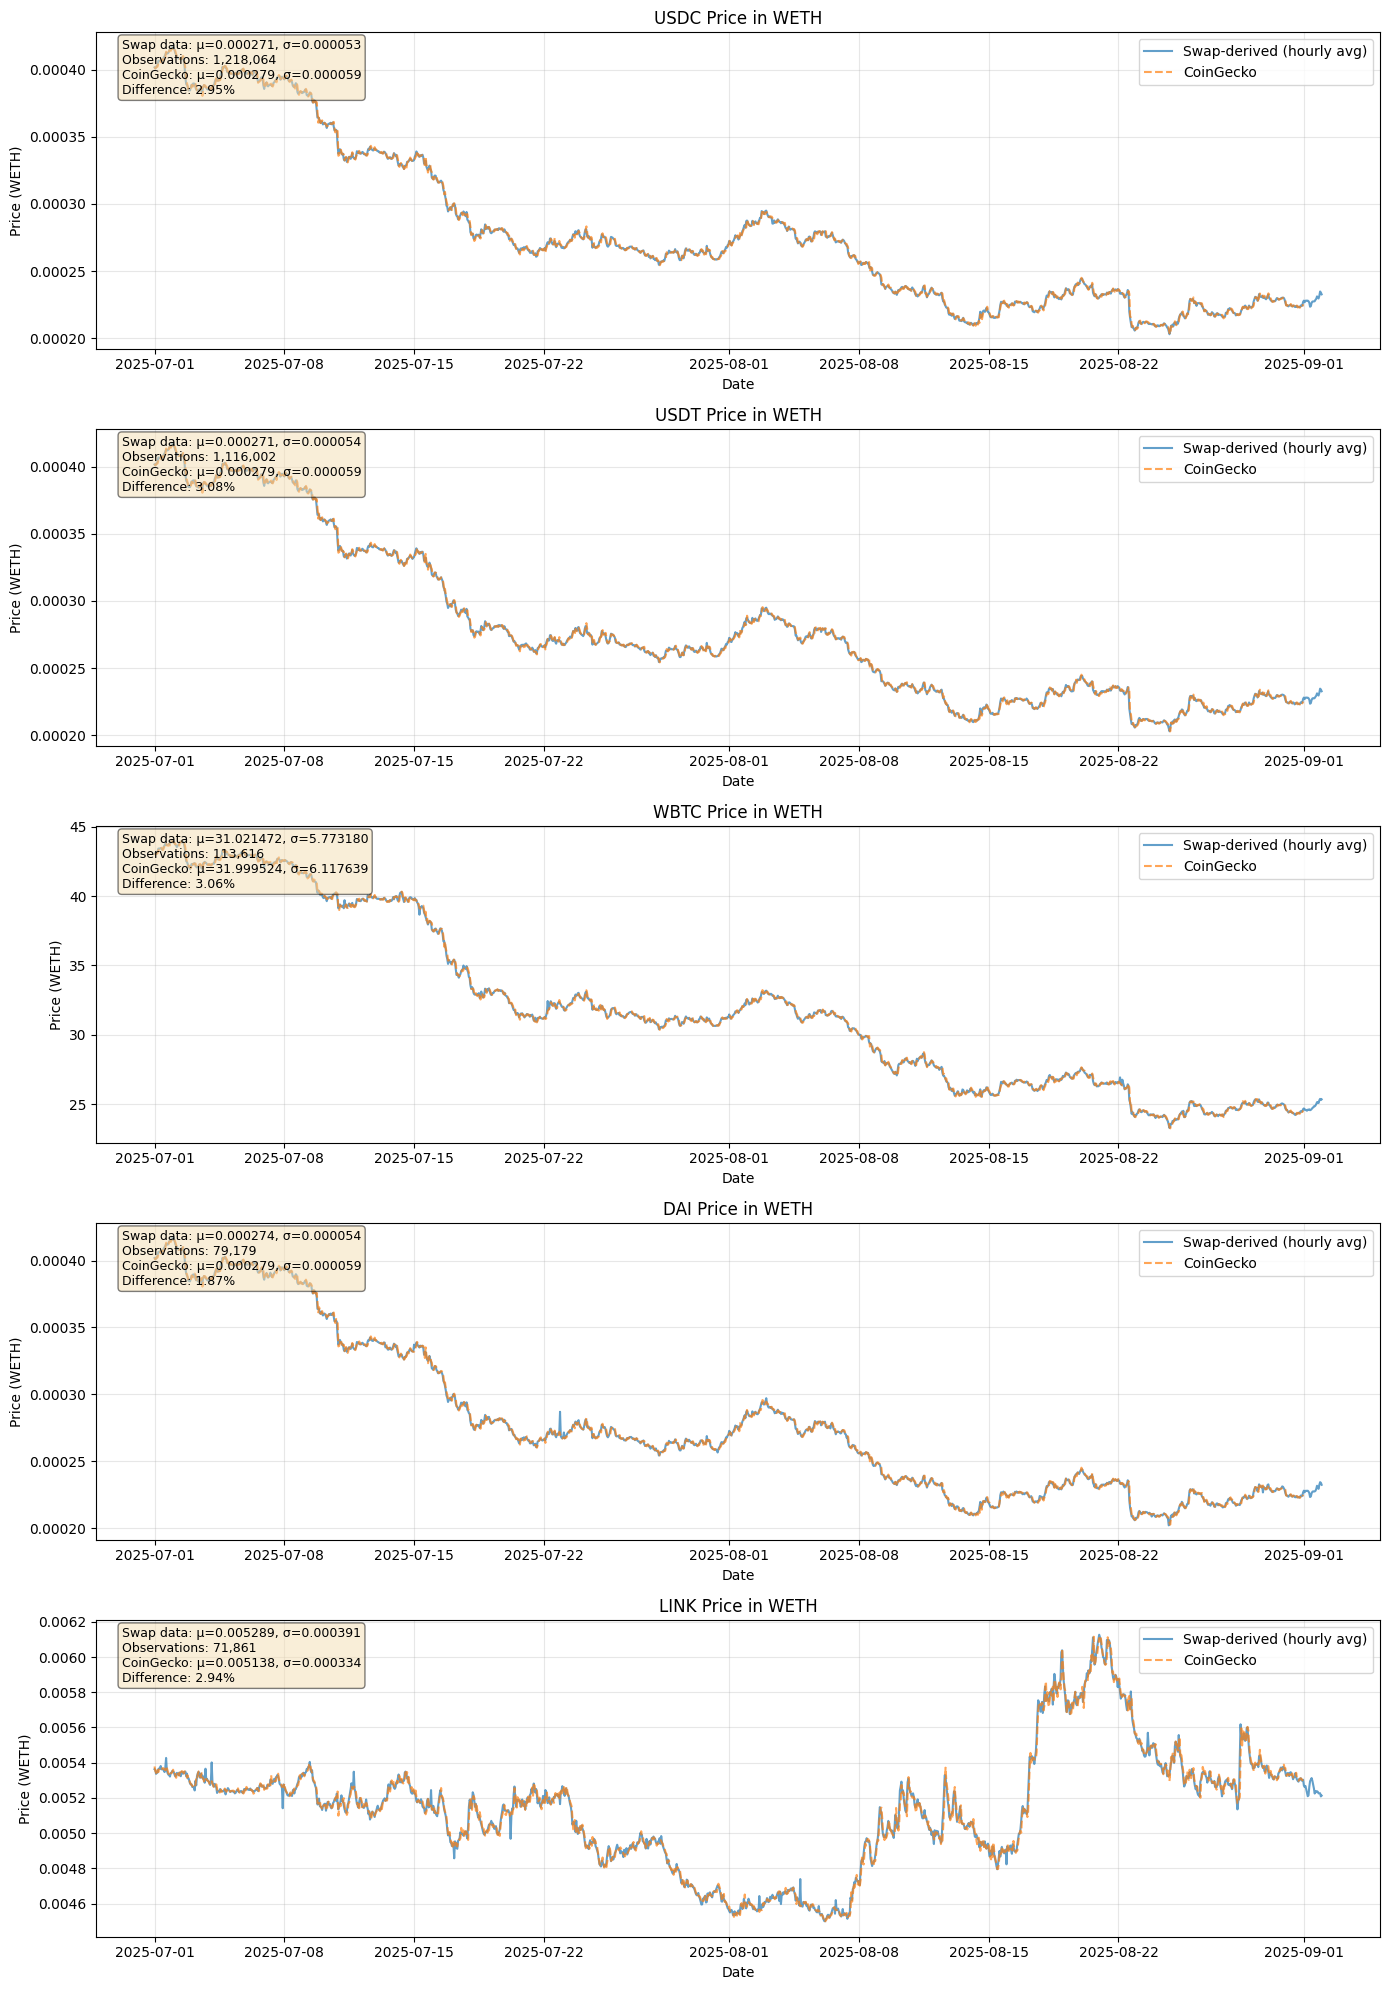

In [5]:
# Plot comparison for each token
fig, axes = plt.subplots(
    len(TOKENS_TO_VALIDATE), 1, figsize=(14, 4 * len(TOKENS_TO_VALIDATE))
)

if len(TOKENS_TO_VALIDATE) == 1:
    axes = [axes]

for idx, (address, info) in enumerate(TOKENS_TO_VALIDATE.items()):
    ax = axes[idx]
    token_name = info["name"]

    # Get our calculated prices for this token
    df_our_prices = df_prices.filter(pl.col("token_address") == address)

    if len(df_our_prices) == 0:
        ax.set_title(f"{token_name} - No swap data available")
        continue

    # Resample to hourly for cleaner visualization
    df_hourly = (
        df_our_prices.sort("block_timestamp")
        .group_by_dynamic("block_timestamp", every="1h")
        .agg(
            [
                pl.col("price_in_weth").mean().alias("price_mean"),
                pl.col("weth_volume").sum().alias("volume"),
            ]
        )
    )

    # Plot our prices
    ax.plot(
        df_hourly["block_timestamp"].to_list(),
        df_hourly["price_mean"].to_list(),
        label="Swap-derived (hourly avg)",
        alpha=0.7,
        linewidth=1.5,
    )

    # Plot CoinGecko prices if available
    if address in coingecko_prices:
        df_cg = coingecko_prices[address]
        ax.plot(
            df_cg["timestamp"].to_list(),
            df_cg["price_eth"].to_list(),
            label="CoinGecko",
            alpha=0.7,
            linewidth=1.5,
            linestyle="--",
        )

    ax.set_title(f"{token_name} Price in WETH")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (WETH)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Add summary statistics
    swap_mean = df_our_prices["price_in_weth"].mean()
    swap_std = df_our_prices["price_in_weth"].std()
    text = f"Swap data: μ={swap_mean:.6f}, σ={swap_std:.6f}\n"
    text += f"Observations: {len(df_our_prices):,}"

    if address in coingecko_prices:
        cg_mean = coingecko_prices[address]["price_eth"].mean()
        cg_std = coingecko_prices[address]["price_eth"].std()
        text += f"\nCoinGecko: μ={cg_mean:.6f}, σ={cg_std:.6f}"
        text += f"\nDifference: {abs(swap_mean - cg_mean) / cg_mean * 100:.2f}%"

    ax.text(
        0.02,
        0.98,
        text,
        transform=ax.transAxes,
        verticalalignment="top",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )

plt.tight_layout()
plt.savefig("../data/price_validation.png", dpi=150, bbox_inches="tight")
print("\nPlot saved to ../data/price_validation.png")
plt.show()

In [6]:
# Calculate correlation and error metrics
print("\n" + "=" * 70)
print("VALIDATION SUMMARY")
print("=" * 70)

for address, info in TOKENS_TO_VALIDATE.items():
    token_name = info["name"]

    df_our = df_prices.filter(pl.col("token_address") == address)

    if len(df_our) == 0 or address not in coingecko_prices:
        continue

    # Resample both to hourly and join
    df_our_hourly = (
        df_our.sort("block_timestamp")
        .group_by_dynamic("block_timestamp", every="1h")
        .agg(pl.col("price_in_weth").mean().alias("swap_price"))
        .with_columns(pl.col("block_timestamp").dt.truncate("1h").alias("hour"))
    )

    df_cg = coingecko_prices[address]
    df_cg_hourly = (
        df_cg.with_columns(pl.col("timestamp").dt.truncate("1h").alias("hour"))
        .group_by("hour")
        .agg(pl.col("price_eth").mean().alias("cg_price"))
    )

    # Join on hour
    df_joined = df_our_hourly.join(df_cg_hourly, on="hour", how="inner")

    if len(df_joined) > 0:
        # Calculate metrics
        correlation = df_joined.select(pl.corr("swap_price", "cg_price").alias("corr"))[
            "corr"
        ][0]

        # Mean absolute percentage error
        mape = (
            (df_joined["swap_price"] - df_joined["cg_price"]).abs()
            / df_joined["cg_price"]
        ).mean() * 100

        print(f"\n{token_name}:")
        print(f"  Correlation: {correlation:.4f}")
        print(f"  MAPE: {mape:.2f}%")
        print(f"  Matched hours: {len(df_joined)}")


VALIDATION SUMMARY

USDC:
  Correlation: 0.9998
  MAPE: 0.31%
  Matched hours: 1487

USDT:
  Correlation: 0.9998
  MAPE: 0.31%
  Matched hours: 1488

WBTC:
  Correlation: 0.9998
  MAPE: 0.25%
  Matched hours: 1487

DAI:
  Correlation: 0.9997
  MAPE: 0.33%
  Matched hours: 1488

LINK:
  Correlation: 0.9971
  MAPE: 0.33%
  Matched hours: 1484
